In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.models.inception import Inception_V3_Weights
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
import os

# Set device (use GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Data transforms (Inception V3 uses 299x299 input)
train_transform = transforms.Compose([
    transforms.Resize(342),
    transforms.CenterCrop(299),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(342),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load full dataset (change path)
dataset_path = '/home/rifat-cou/Documents/Project/Dataset_Raw'  # Folder with class subfolders
full_dataset = datasets.ImageFolder(dataset_path, transform=train_transform)

# Split into train/val (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply val transform to val set (no augmentation)
val_dataset.dataset.transform = val_transform

# Data loaders (batch 32 fits 6GB VRAM; reduce to 16 if OOM)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

# Class names
class_names = full_dataset.classes
print(f"Classes: {class_names}")
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

Classes: ['Chikenpox', 'Cowpox', 'Measles', 'MonkeyPox', 'Normal']
Train samples: 2088, Val samples: 523


In [4]:
# Load pre-trained Inception V3
model = models.inception_v3(weights=Inception_V3_Weights.DEFAULT)

# Freeze all layers except classifier (transfer learning)
for param in model.parameters():
    param.requires_grad = False

# Modify main classifier for 5 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 5)

# Also modify auxiliary classifier if using it during training
model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, 5)

# Move to GPU
model = model.to(device)

# Print model summary (optional)
print(model)

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /home/rifat-cou/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|████████████████████████████████████████| 104M/104M [01:30<00:00, 1.21MB/s]


Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)  # Only train classifier first
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

Epoch 1/100 - Train Loss: 1.6718, Train Acc: 0.5738 | Val Loss: 0.8096, Val Acc: 0.7553
Epoch 2/100 - Train Loss: 1.3201, Train Acc: 0.7184 | Val Loss: 0.6737, Val Acc: 0.7801
Epoch 3/100 - Train Loss: 1.2094, Train Acc: 0.7591 | Val Loss: 0.5929, Val Acc: 0.8203
Epoch 4/100 - Train Loss: 1.1442, Train Acc: 0.7802 | Val Loss: 0.5498, Val Acc: 0.8164
Epoch 5/100 - Train Loss: 1.1085, Train Acc: 0.7883 | Val Loss: 0.5284, Val Acc: 0.8413
Epoch 6/100 - Train Loss: 1.0767, Train Acc: 0.7965 | Val Loss: 0.5120, Val Acc: 0.8317
Epoch 7/100 - Train Loss: 1.0867, Train Acc: 0.7945 | Val Loss: 0.4826, Val Acc: 0.8375
Epoch 8/100 - Train Loss: 1.0451, Train Acc: 0.8099 | Val Loss: 0.4772, Val Acc: 0.8394
Epoch 9/100 - Train Loss: 1.0511, Train Acc: 0.8084 | Val Loss: 0.4862, Val Acc: 0.8260
Epoch 10/100 - Train Loss: 1.0127, Train Acc: 0.8175 | Val Loss: 0.4757, Val Acc: 0.8432
Epoch 11/100 - Train Loss: 1.0158, Train Acc: 0.8233 | Val Loss: 0.5020, Val Acc: 0.8164
Epoch 12/100 - Train Loss: 1.0

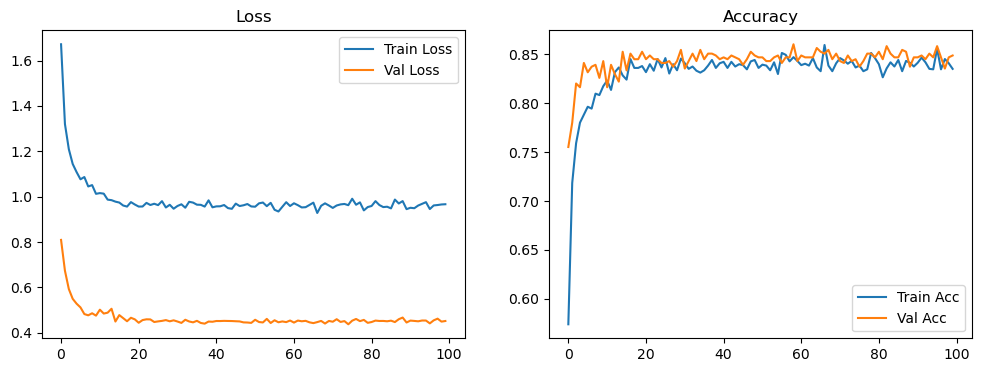

In [6]:
num_epochs = 100
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    # Train
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        if isinstance(outputs, models.inception.InceptionOutputs):  # Handle aux outputs
            main_loss = criterion(outputs.logits, labels)
            aux_loss = criterion(outputs.aux_logits, labels)
            loss = main_loss + 0.3 * aux_loss  # Weighted aux loss
        else:
            loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.logits if isinstance(outputs, models.inception.InceptionOutputs) else outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validate (no aux during eval)
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            if isinstance(outputs, models.inception.InceptionOutputs):
                outputs = outputs.logits  # Use main output only
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)  # Adjust LR
    
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# Plot learning curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

In [7]:
# Predictions and report
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        if isinstance(outputs, models.inception.InceptionOutputs):
            outputs = outputs.logits  # Use main output
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")

model_path = '/home/rifat-cou/Documents/Project/Models'
Inception = os.path.join(model_path, 'InceptionV3')
os.makedirs(Inception, exist_ok=True) 
# Save
torch.save(model.state_dict(), os.path.join(Inception, 'inception_v3_skin_lesion.pth'))

              precision    recall  f1-score   support

   Chikenpox       0.76      0.77      0.76        90
      Cowpox       0.97      0.93      0.95       118
     Measles       0.89      0.79      0.83        98
   MonkeyPox       0.77      0.81      0.79       119
      Normal       0.85      0.94      0.89        98

    accuracy                           0.85       523
   macro avg       0.85      0.85      0.85       523
weighted avg       0.85      0.85      0.85       523

Accuracy: 0.8489
